# SetUp

In [96]:
import mlflow
import os

# import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# import matplotlib.colors as mcolors
# import mpl_toolkits
import json

# import seaborn as sns
# import re
# from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

# from itertools import accumulate

In [97]:
# plt.rcParams.update({'font.size': 12})

In [83]:
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams.update({"font.size": 14})

In [98]:
def legend(ax1, ax2=None, extra_lines=[], extra_labels=[], loc=None):
    lines, labels = ax1.get_legend_handles_labels()
    if ax2 is not None:
        lines2, labels2 = ax2.get_legend_handles_labels()
    else:
        lines2, labels2 = [], []
    by_label = dict(zip(labels + labels2 + extra_labels, lines + lines2 + extra_lines))
    return plt.legend(by_label.values(), by_label.keys(), loc=loc)
    # plt.legend(lines + lines2, labels + labels2)


colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

In [99]:
def DAG_to_pyvis(dag):
    # nt = Network('500px', '500px', directed=True, notebook=True, cdn_resources='remote')
    nt = Network(directed=True)

    for node in dag.nodes:
        size = dag.nodes[node]["size"]
        attrs = {
            "x": None,
            "y": None,
            "physics": True,
            "label": [],
            "color": size_to_color(size),
            "mass": 4,
            "shape": "box",
        }
        if node == "start":
            attrs.update({"x": 1.0, "y": 0.0, "physics": False})
        elif node == "end":
            attrs.update({"x": 15.0, "y": 0.0, "physics": False})
        nt.add_node(node, **attrs)
    for edge in dag.edges:
        prev_node, next_node = edge
        # nt.add_node(prev_node, label=prev_node, title=str(dag.nodes[prev_node]['size']))
        # nt.add_node(next_node, label=next_node, title=str(dag.nodes[next_node]['size']))
        nt.add_edge(prev_node, next_node, title=str(dag.edges[edge]["link"]))

    # print(nt.get_node('start'))
    # nt.toggle_physics(False)
    return nt


def size_to_color(size):
    cmap = mpl.cm.Reds
    norm = mpl.colors.Normalize(vmin=0, vmax=784)
    rgba = cmap(norm(size))
    return mpl.colors.rgb2hex(rgba)

In [100]:
def history_transform(history):
    x, y = [], []
    x_updated, y_updated = [], []
    for i, snapshot in history.items():
        step = int(i)
        for k, v in snapshot.items():
            if v == 2:
                x.append(step)
                y.append(k)
            if v == 1:
                x_updated.append(step)
                y_updated.append(k)
    return x, y, x_updated, y_updated

In [101]:
%cd "/home/tau/sdouka/codebase/tiny.worktrees/"
os.getcwd()

/home/tau/sdouka/codebase/tiny.worktrees


/home/tau/sdouka/miniconda3/envs/tiny/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


'/home/tau/sdouka/codebase/tiny.worktrees'

# Get Experiments

In [102]:
client = mlflow.client.MlflowClient()
# mlflow.set_tracking_uri(uri="http://127.0.0.1:27027")

In [103]:
def get_runs(exp_name):
    experiment = client.get_experiment_by_name(exp_name)
    runs = client.search_runs([experiment.experiment_id])
    print("Number of runs", len(runs))
    runIds = {run.info.run_name: run.info.run_id for run in runs}
    return runIds

In [104]:
runIds = get_runs("MNIST")
runIds

Number of runs 6


{'intertrain_2xdata_minibatch': '6d4a47f20fff456bb8329266d9918e62',
 'intertrain_1xdata': 'd44ccce62ea74c24b7ba59dff47eb3c7',
 'intertrain_2xdata': '22286887ba5d4d3ebb64d6850753ab77',
 'dashing-zebra-525': 'f98f27aeccd14468974869088b43376b',
 'bouncy-sponge-884': '7aeb8a2d3bb245a0bea125c1069f314a',
 'omniscient-bird-518': '0e69feba645845139819a09db4a072f7'}

In [105]:
def get_logs(runIDs):
    if not isinstance(runIDs, list):
        runIDs = [runIDs]
    print(runIDs)

    run_info = {}
    run_info_t = {}
    for runID in runIDs:
        # run_info["steps"].append({item.step: item.step for item in client.get_metric_history})
        retreived_run = client.get_run(runID)

        # Timing
        start_time = retreived_run.info.start_time
        try:
            run_info["duration (ms)"] = retreived_run.info.end_time - start_time
            run_info_t["duration (ms)"] = retreived_run.info.end_time - start_time
            run_info["duration (s)"] = run_info["duration (ms)"] / 1_000
            run_info_t["duration (s)"] = run_info_t["duration (ms)"] / 1_000
            run_info["duration (h)"] = run_info["duration (s)"] / 3_600
            run_info_t["duration (h)"] = run_info_t["duration (s)"] / 3_600
        except:
            print("Could not get duration of run")

        # Run name
        run_name = retreived_run.info.run_name
        if "name" not in run_info:
            run_info["name"] = []
            run_info_t["name"] = []
        run_info["name"].append(run_name)
        run_info_t["name"].append(run_name)

        # Metrics
        for key in tqdm(retreived_run.data.metrics.keys()):
            if ("/node " in key) or ("/edge " in key) or ("/layer " in key):
                continue
            if (
                ("_utilization_" in key)
                or ("_percentage" in key)
                or ("network_" in key)
            ):
                continue

            if key not in run_info:
                run_info[key] = []
                run_info_t[key] = []
            metric_data = client.get_metric_history(runID, key)
            run_info[key].append({item.step: item.value for item in metric_data})
            run_info_t[key].append(
                {
                    (item.timestamp - start_time) / 1_000: item.value
                    for item in metric_data
                }
            )

        # Artifacts
        try:
            # mlflow.artifacts.load_dict("mlflow-artifacts:/235085688558347327/e95c2ea3c22f44cb950829023dffc42e/artifacts/gh.json")
            artifact_uri = mlflow.artifacts.download_artifacts(
                run_id=runID, artifact_path="gh.json"
            )
            with open(artifact_uri, "r") as f:
                data = json.load(f)
            print(f"Got growth history for {artifact_uri}")
            if "growth history" not in run_info:
                run_info["growth history"] = []
            run_info["growth history"].append(data)
        except mlflow.MlflowException as err:
            print(f"[Run {runID}] {err}")
        except Exception as err:
            pass

    return run_info, run_info_t

In [106]:
# run_info, run_info_t = get_logs([runIds["intertrain_1xdata"], runIds["intertrain_2xdata"], runIds["intertrain_2xdata_minibatch"]])
run_info, run_info_t = get_logs([runIds["intertrain_2xdata_minibatch"]])
list(run_info.keys())

['6d4a47f20fff456bb8329266d9918e62']


100%|██████████| 708/708 [00:02<00:00, 284.34it/s] 


Got growth history for /home/tau/sdouka/codebase/tiny.worktrees/mlruns/263444712957661555/6d4a47f20fff456bb8329266d9918e62/artifacts/gh.json


['duration (ms)',
 'duration (s)',
 'duration (h)',
 'name',
 'growth train loss',
 'growth dev loss',
 'dev loss',
 'growth val loss',
 'val loss',
 'test loss',
 'growth train accuracy',
 'growth dev accuracy',
 'dev accuracy',
 'growth val accuracy',
 'val accuracy',
 'test accuracy',
 'system/system_memory_usage_megabytes',
 'system/disk_usage_megabytes',
 'system/disk_available_megabytes',
 'system/gpu_0_memory_usage_megabytes',
 'system/gpu_0_power_usage_watts',
 'system/gpu_1_memory_usage_megabytes',
 'system/gpu_1_power_usage_watts',
 'system/gpu_2_memory_usage_megabytes',
 'system/gpu_2_power_usage_watts',
 'system/gpu_3_memory_usage_megabytes',
 'system/gpu_3_power_usage_watts',
 'Intermediate training/val loss',
 'Intermediate training/val accuracy',
 'Intermediate training/dev loss',
 'Intermediate training/dev accuracy',
 'complexity/flops',
 'complexity/activations',
 'complexity/nb of parameters',
 'codecarbon/duration',
 'codecarbon/emissions',
 'codecarbon/emissions_ra

# Plots

## params vs complexity

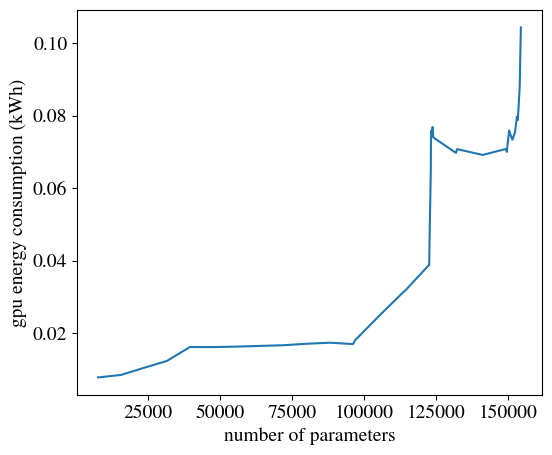

In [84]:
fig, ax1 = plt.subplots(figsize=(6, 5))
for i in range(len(run_info["name"])):
    ax1.plot(
        run_info["complexity/nb of parameters"][i].values(),
        run_info["codecarbon/gpu_energy"][i].values(),
        label=f"per step",
    )
    # ax1.plot(run_info["complexity/nb of parameters"][i].values(), list(accumulate(run_info["codecarbon/gpu_energy"][i].values())), "-", c=colors[1], label=f"cumulative")
# legend(ax1)
ax1.set_xlabel("number of parameters")
ax1.set_ylabel("gpu energy consumption (kWh)")
# ax1.set_xscale("log")
plt.show()

## Random graphs

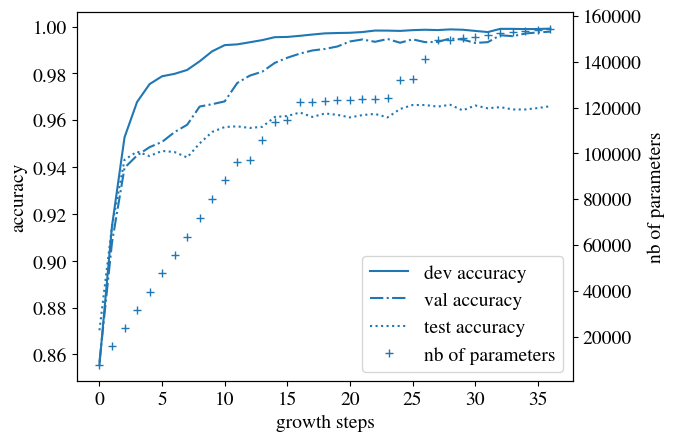

In [85]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
for i in range(len(run_info["name"])):
    ax1.plot(
        run_info["dev accuracy"][i].values(), "-", color=colors[i], label="dev accuracy"
    )
    ax1.plot(
        run_info["val accuracy"][i].values(),
        "-.",
        color=colors[i],
        label="val accuracy",
    )
    ax1.plot(
        run_info["test accuracy"][i].values(),
        ":",
        color=colors[i],
        label="test accuracy",
    )
    ax2.plot(
        run_info["complexity/nb of parameters"][i].values(),
        "+",
        color=colors[i],
        label="nb of parameters",
    )
ax1.set_ylabel("accuracy")
ax2.set_ylabel("nb of parameters")
ax1.set_xlabel("growth steps")
plt.xlabel("steps")
legend(ax1, ax2)
plt.show()

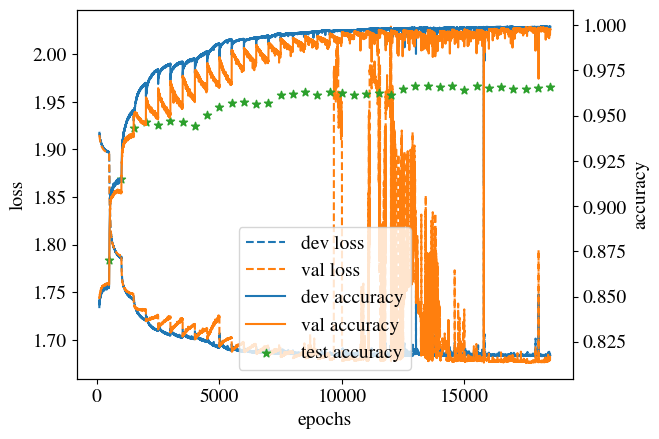

In [86]:
crop = 100  # 00
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
for i in range(len(run_info["name"])):
    ax1.plot(
        list(run_info["Intermediate training/dev loss"][i].keys())[crop:],
        list(run_info["Intermediate training/dev loss"][i].values())[crop:],
        "--",
        color=colors[0],
        label="dev loss",
    )
    ax1.plot(
        list(run_info["Intermediate training/val loss"][i].keys())[crop:],
        list(run_info["Intermediate training/val loss"][i].values())[crop:],
        "--",
        color=colors[1],
        label="val loss",
    )
    ax2.plot(
        list(run_info["Intermediate training/dev accuracy"][i].keys())[crop:],
        list(run_info["Intermediate training/dev accuracy"][i].values())[crop:],
        "-",
        color=colors[0],
        label="dev accuracy",
    )
    ax2.plot(
        list(run_info["Intermediate training/val accuracy"][i].keys())[crop:],
        list(run_info["Intermediate training/val accuracy"][i].values())[crop:],
        "-",
        color=colors[1],
        label="val accuracy",
    )
    # ax1.scatter(run_info['test loss'][i].keys(), run_info['test loss'][i].values(), marker="*", color=colors[2], label="test loss")
    epoch_len = list(run_info["test accuracy"][i].keys())[0]
    crop_acc = int(crop / epoch_len)
    ax2.scatter(
        list(run_info["test accuracy"][i].keys())[crop_acc:],
        list(run_info["test accuracy"][i].values())[crop_acc:],
        marker="*",
        color=colors[2],
        label="test accuracy",
    )
    # ax2.scatter(run_info['growth val accuracy'][i].keys(), run_info['growth val accuracy'][i].values(), marker="*", color=colors[3], label="test accuracy")
    # ax2.scatter(run_info['val accuracy'][i].keys(), run_info['val accuracy'][i].values(), marker="*", color=colors[4], label="test accuracy")
ax1.set_ylabel("loss")
ax2.set_ylabel("accuracy")
ax1.set_xlabel("epochs")
# ax1.set_xscale("symlog")
legend(ax1, ax2)
plt.show()

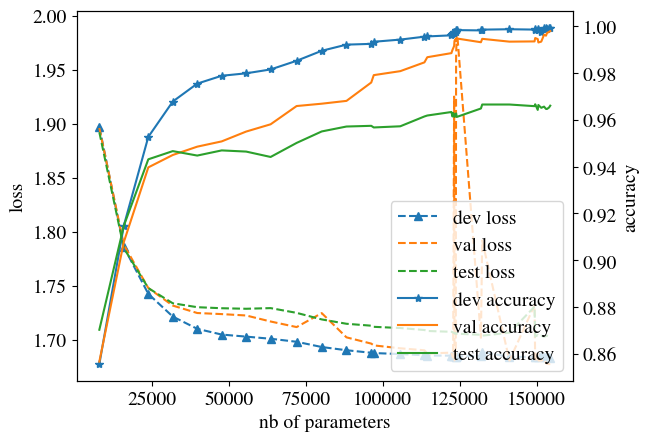

In [87]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
for i in range(len(run_info["name"])):
    ax1.plot(
        run_info["complexity/nb of parameters"][i].values(),
        run_info["dev loss"][i].values(),
        "--^",
        color=colors[0],
        label="dev loss",
    )
    ax1.plot(
        run_info["complexity/nb of parameters"][i].values(),
        run_info["val loss"][i].values(),
        "--",
        color=colors[1],
        label="val loss",
    )
    ax1.plot(
        run_info["complexity/nb of parameters"][i].values(),
        run_info["test loss"][i].values(),
        "--",
        color=colors[2],
        label="test loss",
    )
    ax2.plot(
        run_info["complexity/nb of parameters"][i].values(),
        run_info["dev accuracy"][i].values(),
        "-*",
        color=colors[0],
        label="dev accuracy",
    )
    ax2.plot(
        run_info["complexity/nb of parameters"][i].values(),
        run_info["val accuracy"][i].values(),
        color=colors[1],
        label="val accuracy",
    )
    ax2.plot(
        run_info["complexity/nb of parameters"][i].values(),
        run_info["test accuracy"][i].values(),
        color=colors[2],
        label="test accuracy",
    )
ax1.set_ylabel("loss")
ax2.set_ylabel("accuracy")
ax1.set_xlabel("nb of parameters")
legend(ax1, ax2)
plt.show()

## Zoomed information

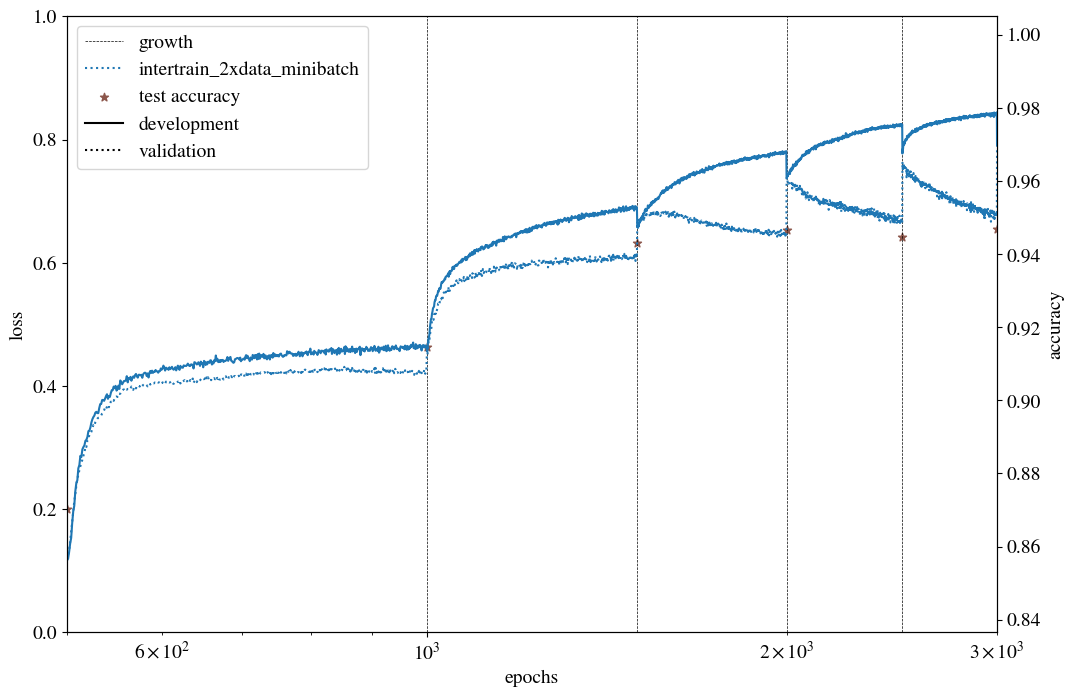

In [88]:
crop = 100  # 00
crop_end = 10_000
fig, ax1 = plt.subplots(figsize=(12, 8))
ax2 = ax1.twinx()

[
    plt.axvline(x=v, linestyle="--", color="k", label="growth", lw=0.5)
    for v in range(500, 3_000, 500)
]
for i in range(len(run_info["name"])):
    # ax1.plot(list(run_info['Intermediate training/dev loss'][i].keys())[crop:], list(run_info['Intermediate training/dev loss'][i].values())[crop:], "-", color=colors[i], label=f"{run_info['name'][i]}")
    # ax1.plot(list(run_info['Intermediate training/val loss'][i].keys())[crop:], list(run_info['Intermediate training/val loss'][i].values())[crop:], ":", color=colors[i], label=f"{run_info['name'][i]}")
    ax2.plot(
        list(run_info["Intermediate training/dev accuracy"][i].keys())[crop:crop_end],
        list(run_info["Intermediate training/dev accuracy"][i].values())[crop:crop_end],
        "-",
        color=colors[i],
        label=f"{run_info['name'][i]}",
    )
    ax2.plot(
        list(run_info["Intermediate training/val accuracy"][i].keys())[crop:crop_end],
        list(run_info["Intermediate training/val accuracy"][i].values())[crop:crop_end],
        ":",
        color=colors[i],
        label=f"{run_info['name'][i]}",
    )
    epoch_len = list(run_info["test accuracy"][i].keys())[0]
    crop_acc = int(crop / epoch_len)
    ax2.scatter(
        list(run_info["test accuracy"][i].keys())[crop_acc:],
        list(run_info["test accuracy"][i].values())[crop_acc:],
        marker="*",
        color=colors[5],
        label="test accuracy",
    )
    ax1.set_ylabel("loss")
ax2.set_ylabel("accuracy")
ax1.set_xlabel("epochs")
ax1.set_xscale("log")


from matplotlib.lines import Line2D

myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle=":"),
]  ##Create custom handles for 2nd legend
# l2 = ax1.legend(handles=myHandle, labels = ['development', 'validation'], bbox_to_anchor=(1.4,1)) ##Add 2nd legend

legend(ax1, ax2, myHandle, ["development", "validation"])
plt.xlim(500, 3_000)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


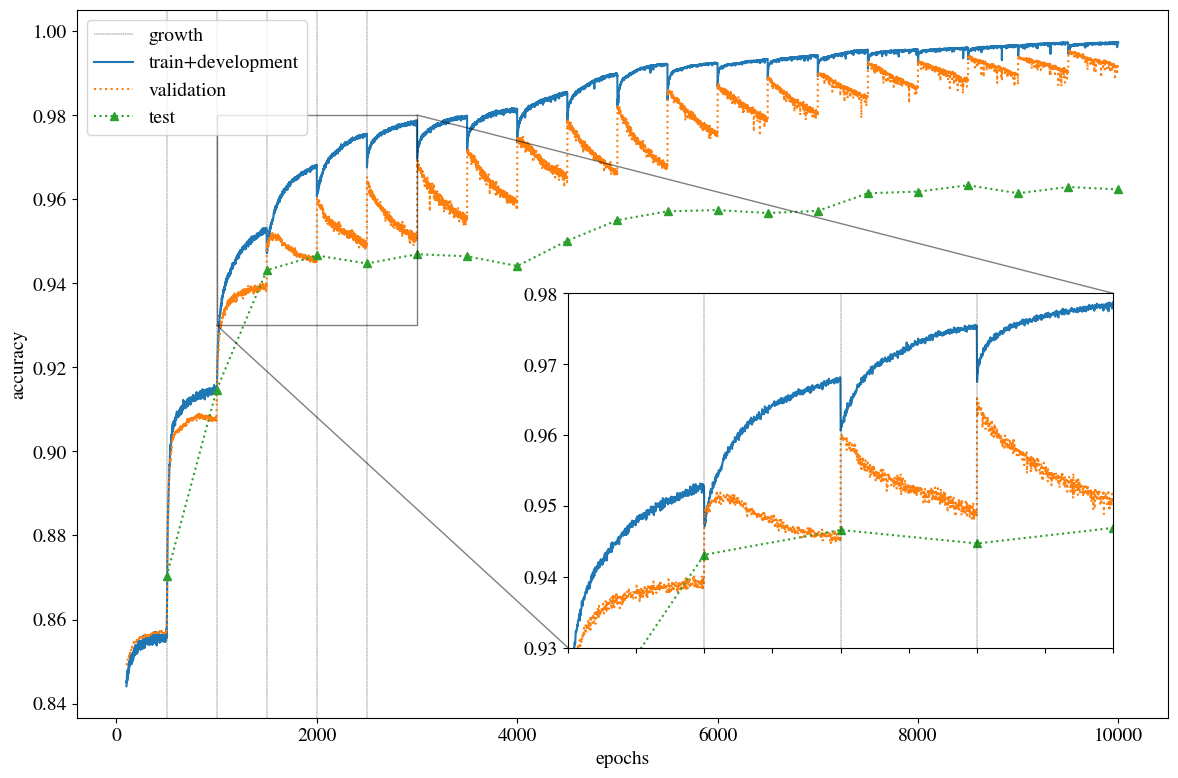

In [89]:
crop = 100  # 00
crop_end = 10_000
fig, ax1 = plt.subplots(figsize=(12, 8))

[
    ax1.axvline(x=v, linestyle="--", color="k", label="growth", lw=0.3)
    for v in range(500, 3_000, 500)
]
for i in range(len(run_info["name"])):
    ax1.plot(
        list(run_info["Intermediate training/dev accuracy"][i].keys())[crop:crop_end],
        list(run_info["Intermediate training/dev accuracy"][i].values())[crop:crop_end],
        "-",
        label=f"train+development",
    )
    ax1.plot(
        list(run_info["Intermediate training/val accuracy"][i].keys())[crop:crop_end],
        list(run_info["Intermediate training/val accuracy"][i].values())[crop:crop_end],
        ":",
        label=f"validation",
    )

    epoch_len = list(run_info["test accuracy"][i].keys())[0]
    crop_start_acc, crop_end_acc = int(crop / epoch_len), int(crop_end / epoch_len)
    ax1.plot(
        list(run_info["test accuracy"][i].keys())[crop_start_acc:crop_end_acc],
        list(run_info["test accuracy"][i].values())[crop_start_acc:crop_end_acc],
        ":^",
        label="test",
    )

zoom_start = 1_000
zoom_end = 3_000

axins = ax1.inset_axes(
    (0.45, 0.1, 0.5, 0.5),
    xlim=(zoom_start, zoom_end),
    ylim=(0.93, 0.98),
    xticklabels=[],  # yticklabels=[]
)
axins.plot(
    list(run_info["Intermediate training/dev accuracy"][i].keys())[zoom_start:zoom_end],
    list(run_info["Intermediate training/dev accuracy"][i].values())[
        zoom_start:zoom_end
    ],
    "-",
)
axins.plot(
    list(run_info["Intermediate training/val accuracy"][i].keys())[zoom_start:zoom_end],
    list(run_info["Intermediate training/val accuracy"][i].values())[
        zoom_start:zoom_end
    ],
    ":",
)
axins.plot(
    list(run_info["test accuracy"][i].keys()),
    list(run_info["test accuracy"][i].values()),
    ":^",
)
[
    axins.axvline(x=v, linestyle="--", color="k", label="growth", lw=0.3)
    for v in range(500, 3_000, 500)
]

ax1.indicate_inset_zoom(axins, edgecolor="black")

legend(ax1, loc="upper left")  # , None, myHandle, ["development", "validation"])
# plt.xlim(500, 3_000)
ax1.set_ylabel("accuracy")
ax1.set_xlabel("epochs")
# ax1.set_xscale("log")
plt.title("")
plt.tight_layout()
plt.savefig("temp/plots/mnist_growth.eps", format="eps")
plt.show()

In [90]:
print("Steps", crop_end / 500)

Steps 20.0


In [91]:
print(list(run_info["test accuracy"][i].values())[-1] * 100)
print(100 - list(run_info["test accuracy"][i].values())[-1] * 100)

96.6
3.4000000000000057


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


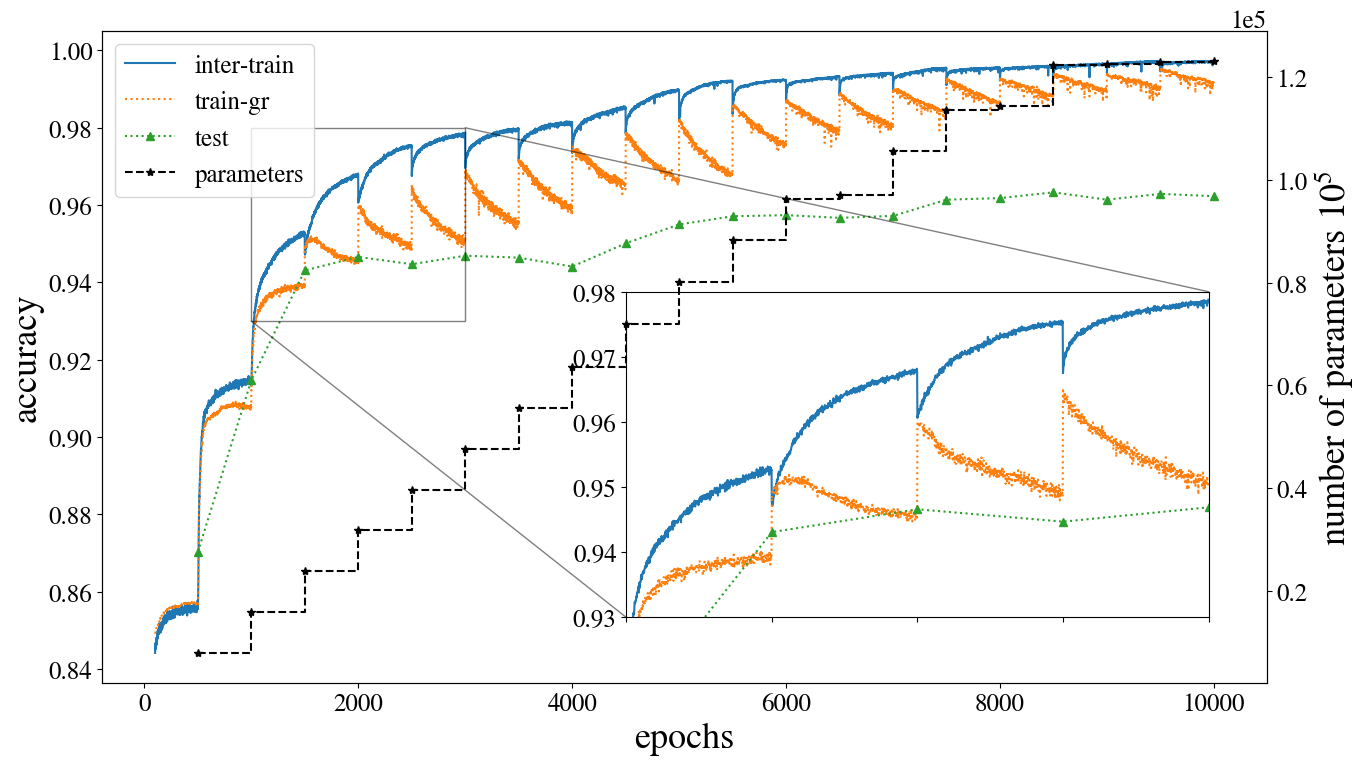

In [117]:
plt.rcParams.update({"font.size": 18})

crop = 100  # 00
crop_end = 10_000
fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# [ax1.axvline(x = v, linestyle="--", color = 'k', label = 'growth', lw=.3) for v in range(500, 3_000, 500)]
for i in range(len(run_info["name"])):
    ax1.plot(
        list(run_info["Intermediate training/dev accuracy"][i].keys())[crop:crop_end],
        list(run_info["Intermediate training/dev accuracy"][i].values())[crop:crop_end],
        "-",
        label=f"inter-train",
    )
    ax1.plot(
        list(run_info["Intermediate training/val accuracy"][i].keys())[crop:crop_end],
        list(run_info["Intermediate training/val accuracy"][i].values())[crop:crop_end],
        ":",
        label=f"train-gr",
    )

    epoch_len = list(run_info["test accuracy"][i].keys())[0]
    crop_start_acc, crop_end_acc = int(crop / epoch_len), int(crop_end / epoch_len)
    ax1.plot(
        list(run_info["test accuracy"][i].keys())[crop_start_acc:crop_end_acc],
        list(run_info["test accuracy"][i].values())[crop_start_acc:crop_end_acc],
        ":^",
        label="test",
    )

    ax2.step(
        list(run_info["complexity/nb of parameters"][i].keys())[
            crop_start_acc:crop_end_acc
        ],
        list(run_info["complexity/nb of parameters"][i].values())[
            crop_start_acc:crop_end_acc
        ],
        "--*k",
        where="post",
        label="parameters",
    )

zoom_start = 1_000
zoom_end = 3_000

axins = ax1.inset_axes(
    (0.45, 0.1, 0.5, 0.5),
    xlim=(zoom_start, zoom_end),
    ylim=(0.93, 0.98),
    xticklabels=[],  # yticklabels=[]
)
axins.plot(
    list(run_info["Intermediate training/dev accuracy"][i].keys())[zoom_start:zoom_end],
    list(run_info["Intermediate training/dev accuracy"][i].values())[
        zoom_start:zoom_end
    ],
    "-",
)
axins.plot(
    list(run_info["Intermediate training/val accuracy"][i].keys())[zoom_start:zoom_end],
    list(run_info["Intermediate training/val accuracy"][i].values())[
        zoom_start:zoom_end
    ],
    ":",
)
axins.plot(
    list(run_info["test accuracy"][i].keys()),
    list(run_info["test accuracy"][i].values()),
    ":^",
)
# [axins.axvline(x = v, linestyle="--", color = 'k', label = 'growth', lw=.3) for v in range(500, 3_000, 500)]

ax1.indicate_inset_zoom(axins, edgecolor="black")

legend(ax1, ax2, loc="upper left")  # , None, myHandle, ["development", "validation"])
# plt.xlim(500, 3_000)
ax1.set_ylabel("accuracy", fontsize=26)
ax1.set_xlabel("epochs", fontsize=26)
# ax1.set_xscale("log")
ax2.set_ylabel(f"number of parameters $10^5$", fontsize=26)
ax2.ticklabel_format(axis="y", scilimits=(-3, 3))
# ax2.set_yscale("log")
plt.title("")
plt.tight_layout()
plt.savefig("temp/plots/mnist_growth_params_wide.eps", format="eps")
plt.show()

plt.rcParams.update({"font.size": 14})

## GPU hours

In [93]:
print(run_info["duration (h)"])

24.160728888888887


dev accuracy 0.99725
test accuracy 0.9623
duration (s) 24084.768
duration (h) 6.690213333333333
duration (d) 0.2787588888888889
duration (d) for 7 hours 0.2916666666666667


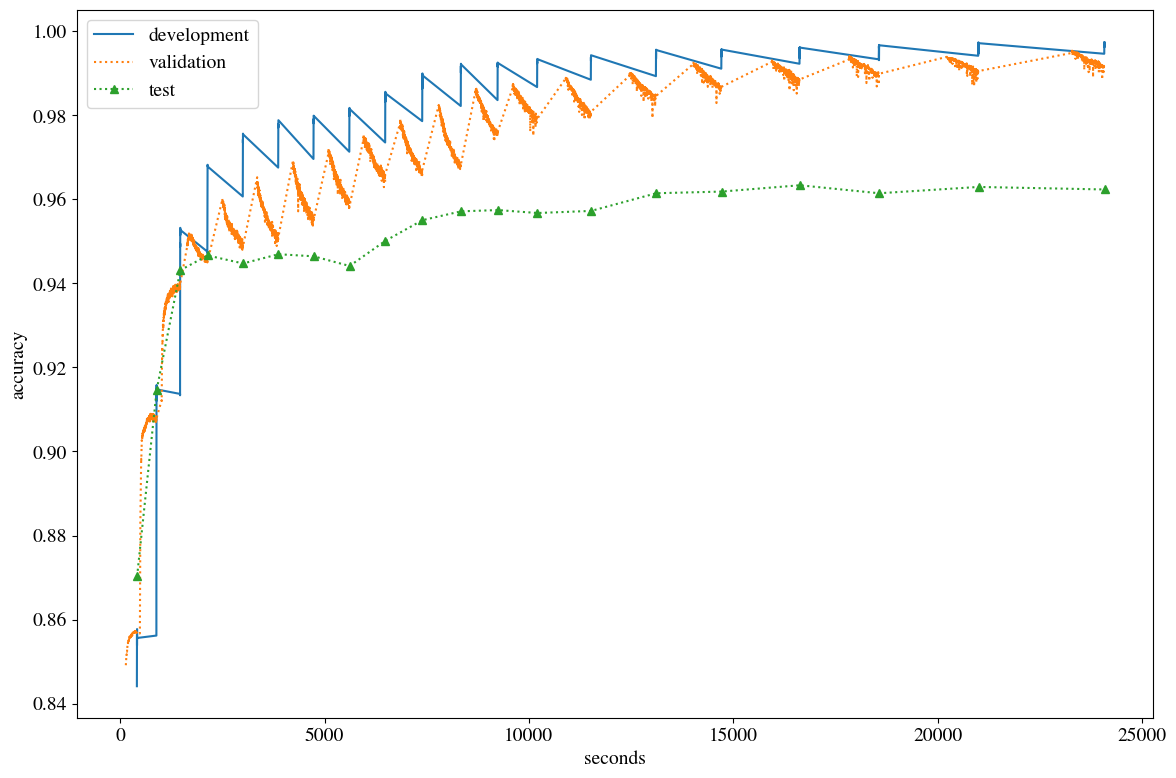

In [94]:
crop = 100  # 00
crop_end = 10_000
fig, ax1 = plt.subplots(figsize=(12, 8))

# [ax1.axvline(x = v, linestyle="--", color = 'k', label = 'growth', lw=.3) for v in range(500, 3_000, 500)]
for i in range(len(run_info_t["name"])):
    ax1.plot(
        list(run_info_t["Intermediate training/dev accuracy"][i].keys())[crop:crop_end],
        list(run_info_t["Intermediate training/dev accuracy"][i].values())[
            crop:crop_end
        ],
        "-",
        label=f"development",
    )
    ax1.plot(
        list(run_info_t["Intermediate training/val accuracy"][i].keys())[crop:crop_end],
        list(run_info_t["Intermediate training/val accuracy"][i].values())[
            crop:crop_end
        ],
        ":",
        label=f"validation",
    )

    epoch_len = list(run_info["test accuracy"][i].keys())[0]
    crop_start_acc, crop_end_acc = int(crop / epoch_len), int(crop_end / epoch_len)
    ax1.plot(
        list(run_info_t["test accuracy"][i].keys())[crop_start_acc:crop_end_acc],
        list(run_info_t["test accuracy"][i].values())[crop_start_acc:crop_end_acc],
        ":^",
        label="test",
    )

print(
    "dev accuracy",
    list(run_info_t["Intermediate training/dev accuracy"][i].values())[crop_end - 1],
)
print("test accuracy", list(run_info_t["test accuracy"][i].values())[crop_end_acc - 1])
print(
    "duration (s)",
    list(run_info_t["Intermediate training/dev accuracy"][i].keys())[crop_end - 1],
)
print(
    "duration (h)",
    list(run_info_t["Intermediate training/dev accuracy"][i].keys())[crop_end - 1]
    / 3_600,
)
print(
    "duration (d)",
    list(run_info_t["Intermediate training/dev accuracy"][i].keys())[crop_end - 1]
    / 3_600
    / 24,
)
print("duration (d) for 7 hours", 7 / 24)
# zoom_start = 1_000
# zoom_end = 3_000

# axins = ax1.inset_axes(
#     (0.45, 0.1, 0.5, 0.5),
#     xlim=(zoom_start, zoom_end), ylim=(0.93, 0.98), xticklabels=[], #yticklabels=[]
#     )
# axins.plot(list(run_info_t['Intermediate training/dev accuracy'][i].keys())[zoom_start:zoom_end], list(run_info_t['Intermediate training/dev accuracy'][i].values())[zoom_start:zoom_end], "-")
# axins.plot(list(run_info_t['Intermediate training/val accuracy'][i].keys())[zoom_start:zoom_end], list(run_info_t['Intermediate training/val accuracy'][i].values())[zoom_start:zoom_end], ":")
# axins.plot(list(run_info_t['test accuracy'][i].keys()), list(run_info_t['test accuracy'][i].values()), ":^")
# [axins.axvline(x = v, linestyle="--", color = 'k', label = 'growth', lw=.3) for v in range(500, 3_000, 500)]

# ax1.indicate_inset_zoom(axins, edgecolor="black")

legend(ax1, loc="upper left")  # , None, myHandle, ["development", "validation"])
# plt.xlim(500, 3_000)
ax1.set_ylabel("accuracy")
ax1.set_xlabel("seconds")
# ax1.set_xscale("log")
plt.title("")
plt.tight_layout()
plt.show()

## Baseline graphs

In [95]:
run_info.keys()

dict_keys(['duration (ms)', 'duration (s)', 'duration (h)', 'name', 'growth train loss', 'growth dev loss', 'dev loss', 'growth val loss', 'val loss', 'test loss', 'growth train accuracy', 'growth dev accuracy', 'dev accuracy', 'growth val accuracy', 'val accuracy', 'test accuracy', 'system/system_memory_usage_megabytes', 'system/disk_usage_megabytes', 'system/disk_available_megabytes', 'system/gpu_0_memory_usage_megabytes', 'system/gpu_0_power_usage_watts', 'system/gpu_1_memory_usage_megabytes', 'system/gpu_1_power_usage_watts', 'system/gpu_2_memory_usage_megabytes', 'system/gpu_2_power_usage_watts', 'system/gpu_3_memory_usage_megabytes', 'system/gpu_3_power_usage_watts', 'Intermediate training/val loss', 'Intermediate training/val accuracy', 'Intermediate training/dev loss', 'Intermediate training/dev accuracy', 'complexity/flops', 'complexity/activations', 'complexity/nb of parameters', 'codecarbon/duration', 'codecarbon/emissions', 'codecarbon/emissions_rate', 'codecarbon/cpu_power

In [96]:
final_acc_dev = (
    list(run_info["Intermediate training/dev accuracy"][i].values())[crop_end_acc - 1]
    * 100
)
final_acc_test = list(run_info["test accuracy"][i].values())[crop_end_acc - 1] * 100
final_nb_params = list(run_info["complexity/nb of parameters"][i].values())[
    crop_end_acc - 1
]
final_gpu_energy = list(run_info["codecarbon/gpu_energy"][i].values())[crop_end_acc - 1]
print(final_acc_dev, final_acc_test, final_nb_params, final_gpu_energy)

72.39750000000001 96.23 123200.0 0.06440821735986901


In [97]:
100 - final_acc_test

3.769999999999996

In [98]:
north_pre_nb_params = 784 * 250 + 250 * 200 + 200 * 10
north_pre_acc_test = 98
print(north_pre_acc_test, north_pre_nb_params)
north_select_nb_params = 784 * 800 + 800 * 70 + 70 * 10
north_select_acc_test = 98.25
print(north_select_acc_test, north_select_nb_params)

98 248000
98.25 683900


In [99]:
layers2_300_distortions_nb_params = 784 * 300 + 300 * 10
layers2_300_distortions_acc_test = 100 - 3.6
print(layers2_300_distortions_nb_params, layers2_300_distortions_acc_test)
layers2_300_nb_params = 784 * 300 + 300 * 10
layers2_300_acc_test = 100 - 4.7
print(layers2_300_nb_params, layers2_300_acc_test)
layers2_1000_distortions_nb_params = 784 * 1000 + 1000 * 10
layers2_1000_distortions_acc_test = 100 - 3.8
print(layers2_1000_distortions_nb_params, layers2_1000_distortions_acc_test)
layers2_1000_nb_params = 784 * 1000 + 1000 * 10
layers2_1000_acc_test = 100 - 4.5
print(layers2_1000_nb_params, layers2_1000_acc_test)
layers3_300_100_nb_params = 784 * 300 + 300 * 100 + 100 * 10
layers3_300_100_acc_test = 100 - 3.05
print(layers3_300_100_nb_params, layers3_300_100_acc_test)

238200 96.4
238200 95.3
794000 96.2
794000 95.5
266200 96.95


In [100]:
crop_end_acc

20

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


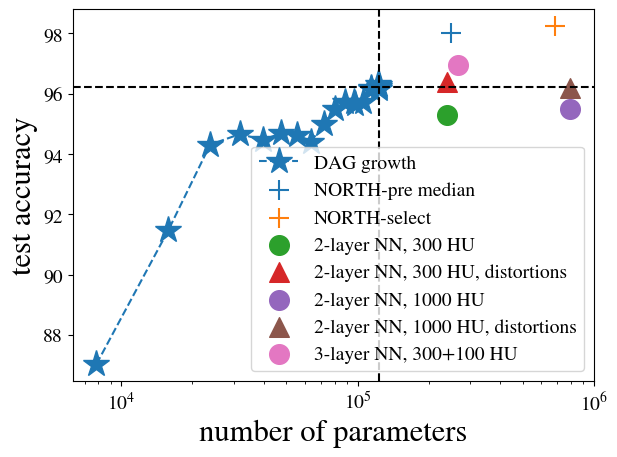

In [121]:
fig, ax1 = plt.subplots()
size = 200

plt.plot(
    list(run_info_t["complexity/nb of parameters"][i].values())[:20],
    list(map(lambda x: x * 100, run_info_t["test accuracy"][i].values()))[:20],
    "--*",
    markersize=size / 10,
    label="DAG growth",
)
# plt.scatter(final_nb_params, final_acc_test, marker="*", label="DAG")
plt.axvline(final_nb_params, linestyle="--", c="black")
plt.axhline(final_acc_test, linestyle="--", c="black")

plt.scatter(
    north_pre_nb_params,
    north_pre_acc_test,
    marker="+",
    s=size,
    label="NORTH-pre median",
)
plt.scatter(
    north_select_nb_params,
    north_select_acc_test,
    marker="+",
    s=size,
    label="NORTH-select",
)

plt.scatter(
    layers2_300_nb_params, layers2_300_acc_test, s=size, label="2-layer NN, 300 HU"
)
plt.scatter(
    layers2_300_distortions_nb_params,
    layers2_300_distortions_acc_test,
    marker="^",
    s=size,
    label="2-layer NN, 300 HU, distortions",
)
plt.scatter(
    layers2_1000_nb_params, layers2_1000_acc_test, s=size, label="2-layer NN, 1000 HU"
)
plt.scatter(
    layers2_1000_distortions_nb_params,
    layers2_1000_distortions_acc_test,
    marker="^",
    s=size,
    label="2-layer NN, 1000 HU, distortions",
)
plt.scatter(
    layers3_300_100_nb_params,
    layers3_300_100_acc_test,
    s=size,
    label="3-layer NN, 300+100 HU",
)

legend(ax1)
plt.xlabel("number of parameters", fontsize=22)
plt.ylabel("test accuracy", fontsize=22)
plt.xscale("log")
plt.tight_layout()
plt.savefig("temp/plots/mnist_baselines.eps", format="eps")
plt.show()

## Split loss and accuracy

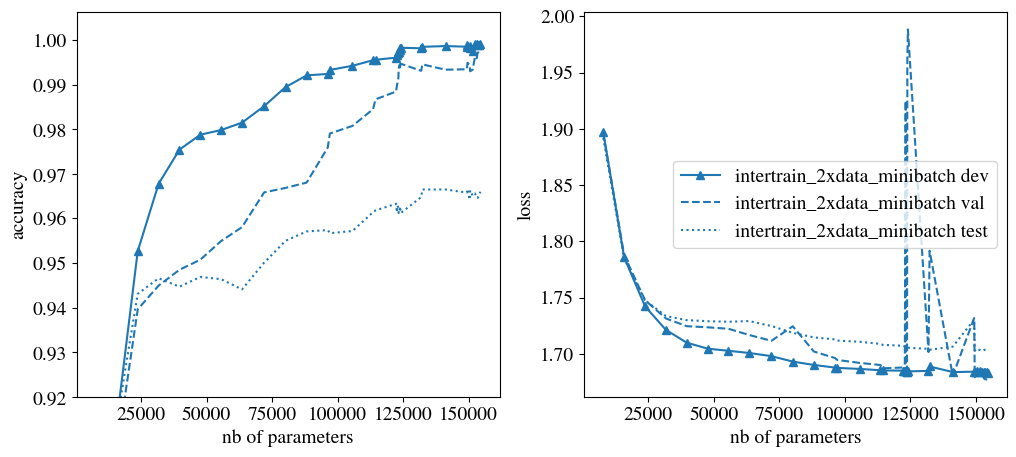

In [102]:
crop = None
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
for i in range(len(run_info["name"])):
    ax1.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["dev accuracy"][i].values())[:crop],
        "-^",
        color=colors[i],
        label=f'{run_info["name"][i]} dev',
    )
    ax1.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["val accuracy"][i].values())[:crop],
        "--",
        color=colors[i],
        label=f'{run_info["name"][i]} val',
    )
    ax1.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["test accuracy"][i].values())[:crop],
        ":",
        color=colors[i],
        label=f'{run_info["name"][i]} test',
    )

    ax2.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["dev loss"][i].values())[:crop],
        "-^",
        color=colors[i],
        label=f'{run_info["name"][i]} dev',
    )
    ax2.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["val loss"][i].values())[:crop],
        "--",
        color=colors[i],
        label=f'{run_info["name"][i]} val',
    )
    ax2.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["test loss"][i].values())[:crop],
        ":",
        color=colors[i],
        label=f'{run_info["name"][i]} test',
    )
ax1.set_ylabel("accuracy")
ax2.set_ylabel("loss")
ax1.set_xlabel("nb of parameters")
ax2.set_xlabel("nb of parameters")
# ax1.set_xscale("log")
ax1.set_ylim(bottom=0.92)
legend(ax1, ax2)
plt.show()

## GPU and FLOPS

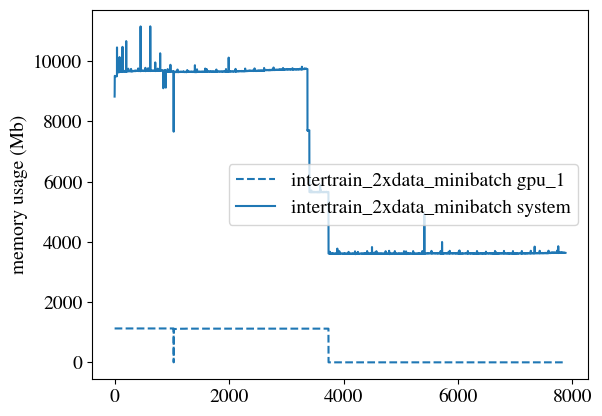

In [103]:
crop = None
fig, ax1 = plt.subplots()
for i in range(len(run_info["name"])):
    # ax1.plot(list(run_info['system/gpu_0_memory_usage_megabytes'][i].values())[:crop], '-', color=colors[i], label=f'{run_info["name"][i]} gpu_0')
    ax1.plot(
        list(run_info["system/gpu_1_memory_usage_megabytes"][i].values())[:crop],
        "--",
        color=colors[i],
        label=f'{run_info["name"][i]} gpu_1',
    )
    ax1.plot(
        list(run_info["system/system_memory_usage_megabytes"][i].values())[:crop],
        "-",
        color=colors[i],
        label=f'{run_info["name"][i]} system',
    )
ax1.set_ylabel("memory usage (Mb)")
# ax1.set_xlabel('nb of parameters')
# ax1.set_xscale("log")
legend(ax1)
plt.show()

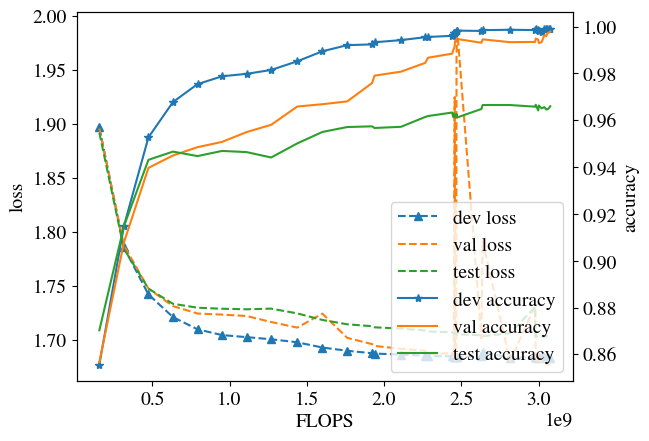

In [104]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
for i in range(len(run_info["name"])):
    ax1.plot(
        run_info["complexity/flops"][i].values(),
        run_info["dev loss"][i].values(),
        "--^",
        color=colors[0],
        label="dev loss",
    )
    ax1.plot(
        run_info["complexity/flops"][i].values(),
        run_info["val loss"][i].values(),
        "--",
        color=colors[1],
        label="val loss",
    )
    ax1.plot(
        run_info["complexity/flops"][i].values(),
        run_info["test loss"][i].values(),
        "--",
        color=colors[2],
        label="test loss",
    )
    ax2.plot(
        run_info["complexity/flops"][i].values(),
        run_info["dev accuracy"][i].values(),
        "-*",
        color=colors[0],
        label="dev accuracy",
    )
    ax2.plot(
        run_info["complexity/flops"][i].values(),
        run_info["val accuracy"][i].values(),
        color=colors[1],
        label="val accuracy",
    )
    ax2.plot(
        run_info["complexity/flops"][i].values(),
        run_info["test accuracy"][i].values(),
        color=colors[2],
        label="test accuracy",
    )
ax1.set_ylabel("loss")
ax2.set_ylabel("accuracy")
ax1.set_xlabel("FLOPS")
legend(ax1, ax2)
plt.show()

In [105]:
print(run_info_t["system/gpu_0_memory_usage_megabytes"][0])
print(run_info_t["dev loss"][0])

{10.308: 653.1, 20.698: 779.0, 30.87: 1160.6, 41.03: 1351.5, 51.197: 1351.5, 61.317: 1477.3, 71.529: 1477.3, 81.676: 1477.3, 91.916: 1605.2, 102.093: 1605.2, 112.228: 1605.2, 122.365: 1605.2, 132.533: 1605.2, 142.684: 1605.2, 152.81: 1605.2, 163.066: 1605.2, 173.217: 1605.2, 183.422: 1605.2, 193.553: 1605.2, 203.693: 1605.2, 213.898: 1605.2, 224.099: 1605.2, 234.293: 1605.2, 244.463: 1605.2, 254.642: 1605.2, 264.824: 1605.2, 275.029: 1605.2, 285.186: 1605.2, 295.381: 1605.2, 305.563: 1605.2, 315.744: 1605.2, 325.921: 1605.2, 336.094: 1605.2, 346.232: 1605.2, 356.368: 1605.2, 366.532: 1605.2, 376.741: 1605.2, 386.918: 1605.2, 397.072: 1605.2, 407.474: 1605.2, 417.615: 1605.2, 427.763: 1605.2, 437.963: 1952.3, 448.16: 1605.2, 458.387: 1605.2, 468.626: 1605.2, 478.922: 1605.2, 489.146: 1605.2, 499.345: 1605.2, 509.628: 1605.2, 519.864: 1605.2, 530.086: 1605.2, 540.295: 1605.2, 550.581: 1605.2, 560.809: 1605.2, 571.056: 1605.2, 581.254: 1605.2, 591.456: 1605.2, 602.012: 1605.2, 612.247: 16

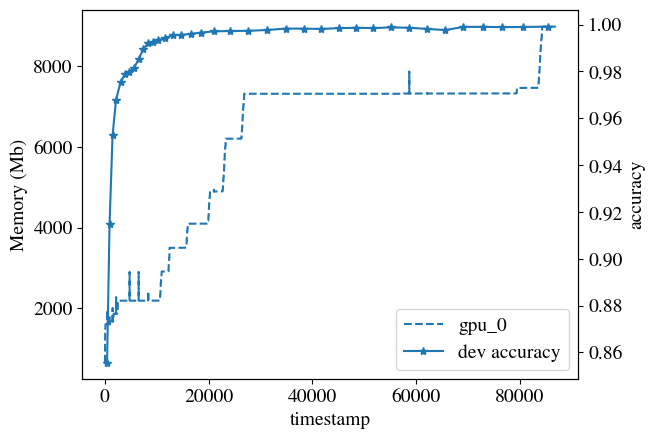

In [106]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
for i in range(len(run_info_t["name"])):
    ax1.plot(
        run_info_t["system/gpu_0_memory_usage_megabytes"][i].keys(),
        run_info_t["system/gpu_0_memory_usage_megabytes"][i].values(),
        "--",
        label="gpu_0",
    )
    # plt.plot(run_info_t['system/system_memory_usage_megabytes'][i].values(), '--', label='system')
    ax2.plot(
        run_info_t["dev accuracy"][i].keys(),
        run_info_t["dev accuracy"][i].values(),
        "-*",
        label="dev accuracy",
    )
ax1.set_ylabel("Memory (Mb)")
ax2.set_ylabel("accuracy")
ax1.set_xlabel("timestamp")
legend(ax1, ax2)
plt.show()

# End